In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.linear_model import LinearRegression

plt.style.use("default")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [73]:
# ==========================================
# Load Processed Datasets
# ==========================================

fund_master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

benchmark = pd.read_csv("../data/processed/10_benchmark_indices_cleaned.csv")

performance = pd.read_csv("../data/processed/scheme_performance_cleaned.csv")

aum = pd.read_csv("../data/processed/03_aum_by_fund_house_cleaned.csv")

sip = pd.read_csv("../data/processed/04_monthly_sip_inflows_cleaned.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_cleaned.csv")

holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")

folio = pd.read_csv("../data/processed/06_industry_folio_count_cleaned.csv")

print("All datasets loaded successfully.")

All datasets loaded successfully.


In [74]:
# ==========================================
# Convert Dates
# ==========================================

nav["date"] = pd.to_datetime(nav["date"])

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Date Conversion Completed")

Date Conversion Completed


In [75]:
print("="*50)
print("DATASET SHAPES")
print("="*50)

print("Fund Master :", fund_master.shape)
print("NAV History :", nav.shape)
print("Benchmark   :", benchmark.shape)
print("Performance :", performance.shape)

DATASET SHAPES
Fund Master : (40, 15)
NAV History : (46000, 3)
Benchmark   : (8050, 3)
Performance : (40, 19)


In [76]:
# ==========================================
# Compute Daily Returns
# ==========================================

nav = nav.sort_values(
    by=["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

print("Daily Returns Computed Successfully")

Daily Returns Computed Successfully


In [77]:
nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [78]:
print(nav["daily_return"].describe())

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


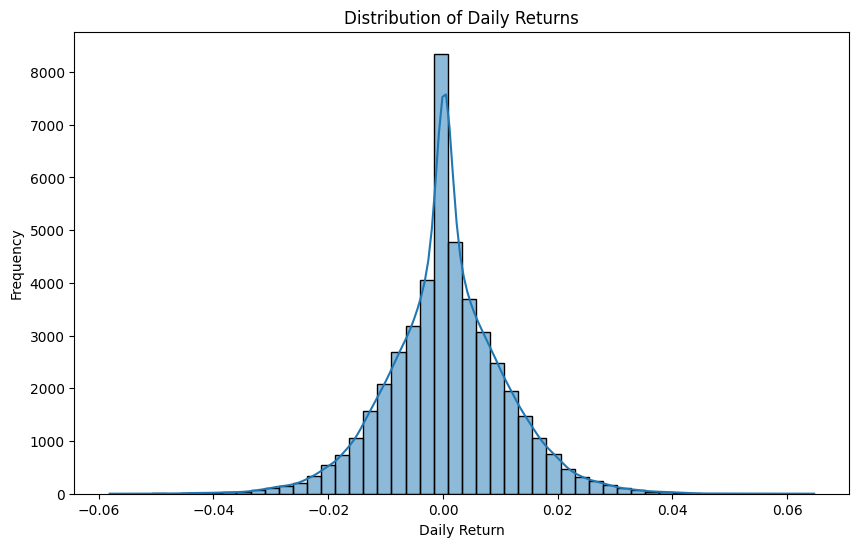

In [79]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.show()

In [80]:
# ==========================================
# CAGR Function
# ==========================================

def calculate_cagr(start_nav, end_nav, years):

    if pd.isna(start_nav) or pd.isna(end_nav):
        return np.nan

    if start_nav <= 0 or years <= 0:
        return np.nan

    return ((end_nav / start_nav) ** (1 / years) - 1) * 100

In [81]:
# ==========================================
# CAGR (1Y, 3Y, 5Y)
# ==========================================

from pandas import DateOffset

cagr_summary = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    latest = group.iloc[-1]

    latest_date = latest["date"]
    latest_nav = latest["nav"]

    def get_nav(years):

        target_date = latest_date - DateOffset(years=years)

        temp = group[group["date"] <= target_date]

        if temp.empty:
            return np.nan

        return temp.iloc[-1]["nav"]

    nav_1y = get_nav(1)
    nav_3y = get_nav(3)
    nav_5y = get_nav(5)

    cagr_summary.append({

        "amfi_code": amfi_code,

        "CAGR_1Y": calculate_cagr(nav_1y, latest_nav, 1),

        "CAGR_3Y": calculate_cagr(nav_3y, latest_nav, 3),

        "CAGR_5Y": calculate_cagr(nav_5y, latest_nav, 5)

    })

cagr_summary = pd.DataFrame(cagr_summary)

print("1Y, 3Y and 5Y CAGR Calculated Successfully")

1Y, 3Y and 5Y CAGR Calculated Successfully


In [82]:
top_cagr = cagr_summary.sort_values(
    by="CAGR_3Y",
    ascending=False
)

top_cagr.head(10)

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
16,119094,22.261065,35.111802,NaN
34,148567,20.360678,34.000916,NaN
24,120504,13.064279,32.487429,NaN
2,100033,53.232396,32.442459,NaN
25,120505,29.604659,31.777537,NaN
19,119551,60.437341,30.456524,NaN
30,120843,26.657082,29.582770,NaN
36,148569,39.751761,29.178902,NaN
3,101206,47.924120,28.967695,NaN
39,149324,65.138719,27.000427,NaN


In [83]:
cagr_summary.to_csv(
    "../reports/cagr_summary.csv",
    index=False
)

print("cagr_summary.csv Saved Successfully")

cagr_summary.csv Saved Successfully


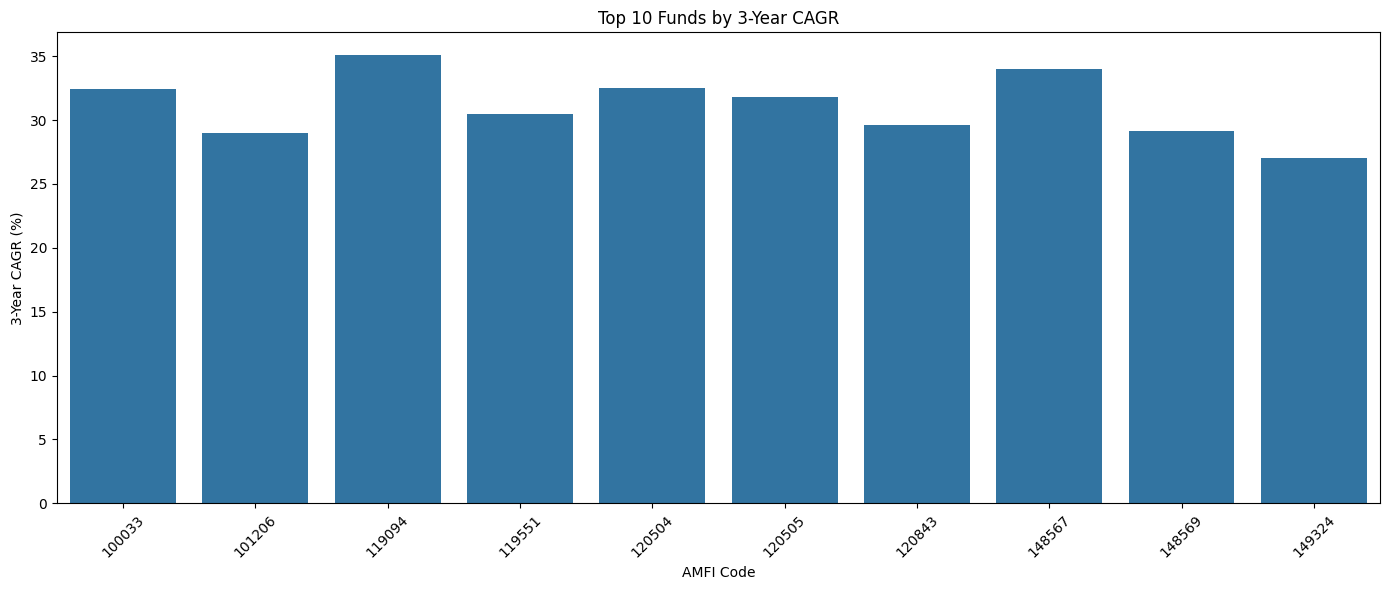

In [84]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=top_cagr.head(10),
    x="amfi_code",
    y="CAGR_3Y"
)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("AMFI Code")
plt.ylabel("3-Year CAGR (%)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/top10_cagr_3y.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## 📈 CAGR Analysis (1Y, 3Y & 5Y)

### Objective

Evaluate the annualized growth rate of mutual fund schemes over different investment horizons.

### Business Insight

1-Year and 3-Year CAGR values were successfully calculated using the available NAV history. The dataset contains less than 5 years of NAV data, so 5-Year CAGR is unavailable (`NaN`) for all schemes due to insufficient historical observations.

In [85]:
cagr_summary.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-2.224271,1.292649,NaN
1,100025,3.704969,3.916390,NaN
2,100033,53.232396,32.442459,NaN
3,101206,47.924120,28.967695,NaN
4,101207,-23.986032,-4.152381,NaN


In [86]:
cagr_summary.isna().sum()

amfi_code     0
CAGR_1Y       0
CAGR_3Y       0
CAGR_5Y      40
dtype: int64

In [87]:
# ==========================================
# Risk Free Rate
# ==========================================

risk_free_rate = 0.065      # 6.5% annual
daily_rf = risk_free_rate / 252

print("Daily Risk-Free Rate:", daily_rf)

Daily Risk-Free Rate: 0.00025793650793650796


In [88]:
# ==========================================
# Sharpe Ratio Calculation
# ==========================================

sharpe_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    avg_return = returns.mean()

    std_return = returns.std()

    sharpe = ((avg_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": amfi_code,
        "average_return": avg_return,
        "volatility": std_return,
        "sharpe_ratio": sharpe
    })

sharpe_df = pd.DataFrame(sharpe_results)

print("Sharpe Ratio Calculated Successfully")

Sharpe Ratio Calculated Successfully


In [89]:
sharpe_df = sharpe_df.sort_values(
    by="sharpe_ratio",
    ascending=False
)

sharpe_df.head(10)

,amfi_code,average_return,volatility,sharpe_ratio
34,148567,0.001074,0.008941,1.448291
30,120843,0.001082,0.010008,1.306744
36,148569,0.001124,0.011134,1.234930
19,119551,0.000917,0.008656,1.208267
25,120505,0.001161,0.012152,1.180101
38,149323,0.001055,0.011179,1.132122
2,100033,0.001080,0.011929,1.093699
9,118632,0.000865,0.008913,1.081659
3,101206,0.000852,0.009177,1.027213
24,120504,0.000843,0.009048,1.026524


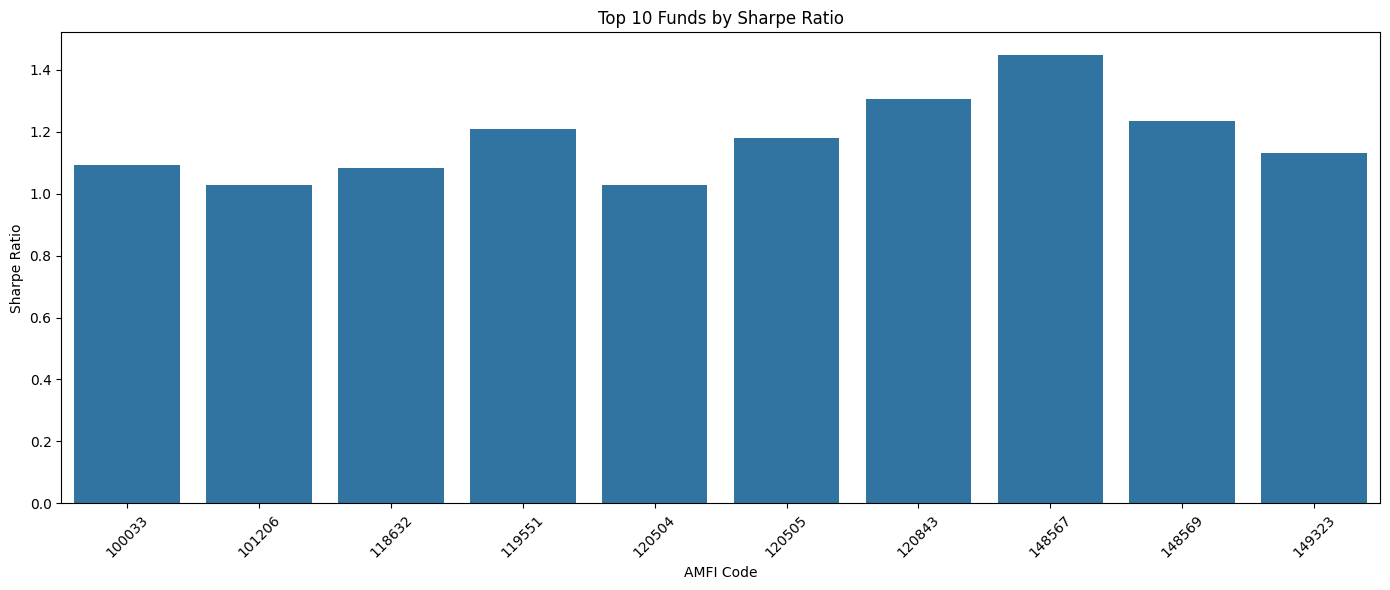

In [90]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=sharpe_df.head(10),
    x="amfi_code",
    y="sharpe_ratio"
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

## 📈 Sharpe Ratio

### Objective

Evaluate the risk-adjusted performance of each mutual fund by comparing its average return with its volatility.

### Business Insight

Funds with higher Sharpe Ratios provide better returns for each unit of risk taken. A higher Sharpe Ratio generally indicates a more efficient and attractive investment.

In [91]:
sharpe_df.describe()

,amfi_code,average_return,volatility,sharpe_ratio
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.000631,0.009414,0.537220
std,14534.998667,0.000348,0.004205,0.573689
min,100016.000000,0.000110,0.000311,-0.815567
25%,118632.750000,0.000273,0.008724,0.064696
50%,119551.500000,0.000648,0.009171,0.647043
75%,120842.250000,0.000878,0.011458,1.005304
max,149324.000000,0.001201,0.016251,1.448291


In [92]:
# ==========================================
# Sortino Ratio Calculation
# ==========================================

sortino_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    avg_return = returns.mean()

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        downside_std = np.nan
    else:
        downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = ((avg_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": amfi_code,
        "average_return": avg_return,
        "downside_deviation": downside_std,
        "sortino_ratio": sortino
    })

sortino_df = pd.DataFrame(sortino_results)

print("Sortino Ratio Calculated Successfully")

Sortino Ratio Calculated Successfully


In [93]:
sortino_df = sortino_df.sort_values(
    by="sortino_ratio",
    ascending=False
)

sortino_df.head(10)

,amfi_code,average_return,downside_deviation,sortino_ratio
34,148567,0.001074,0.005428,2.385644
30,120843,0.001082,0.005531,2.364320
36,148569,0.001124,0.006404,2.146914
19,119551,0.000917,0.004887,2.140267
25,120505,0.001161,0.007067,2.029353
38,149323,0.001055,0.006750,1.875101
9,118632,0.000865,0.005211,1.850133
2,100033,0.001080,0.007133,1.829134
24,120504,0.000843,0.005145,1.805294
3,101206,0.000852,0.005238,1.799563


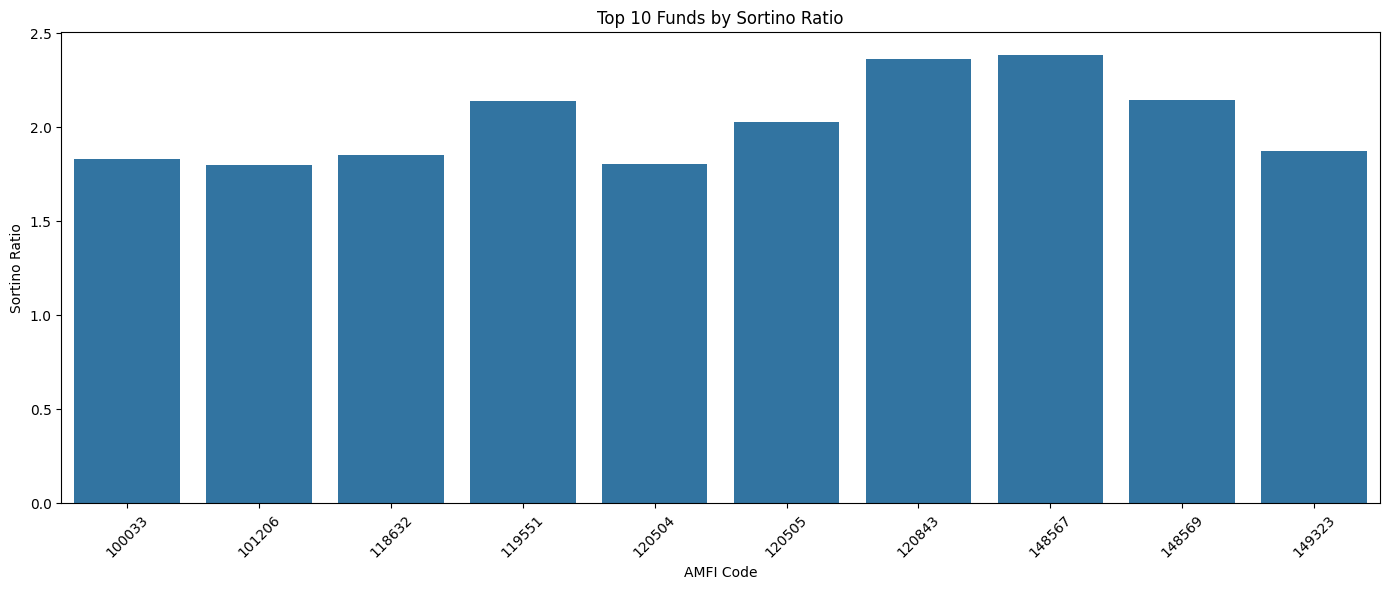

In [94]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=sortino_df.head(10),
    x="amfi_code",
    y="sortino_ratio"
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

## 📈 Sortino Ratio

### Objective

Measure the risk-adjusted performance of mutual funds by considering only downside risk.

### Business Insight

Funds with higher Sortino Ratios generated stronger returns while minimizing negative return volatility, making them attractive for risk-conscious investors.

In [95]:
sortino_df.describe()

,amfi_code,average_return,downside_deviation,sortino_ratio
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.000631,0.005508,0.923338
std,14534.998667,0.000348,0.002493,1.005410
min,100016.000000,0.000110,0.000147,-1.681038
25%,118632.750000,0.000273,0.004918,0.106664
50%,119551.500000,0.000648,0.005408,1.116936
75%,120842.250000,0.000878,0.006840,1.727739
max,149324.000000,0.001201,0.009558,2.385644


In [96]:
benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='object')

In [97]:
# ==========================================
# Benchmark Daily Returns
# ==========================================

benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    by=["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark.head()

,date,index_name,close_value,benchmark_return
3450,2022-01-03,BSE_SMALLCAP,26554.60,NaN
3451,2022-01-04,BSE_SMALLCAP,27079.92,0.019783
3452,2022-01-05,BSE_SMALLCAP,27313.35,0.008620
3453,2022-01-06,BSE_SMALLCAP,27377.05,0.002332
3454,2022-01-07,BSE_SMALLCAP,26316.86,-0.038726


In [98]:
# ==========================================
# NIFTY50 Benchmark
# ==========================================

nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50[
    ["date", "benchmark_return"]
]

print(nifty50.head())
print("Rows:", len(nifty50))

        date  benchmark_return
0 2022-01-03               NaN
1 2022-01-04          0.011253
2 2022-01-05          0.008220
3 2022-01-06          0.002437
4 2022-01-07         -0.006676
Rows: 1150


In [99]:
# ==========================================
# Alpha & Beta
# ==========================================

from scipy.stats import linregress

alpha_beta_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    merged = pd.merge(
        group,
        nifty50,
        on="date",
        how="inner"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope

    alpha = intercept * 252

    alpha_beta_results.append({
        "amfi_code": amfi_code,
        "alpha": alpha,
        "beta": beta
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)

print("Alpha & Beta Calculated Successfully")

Alpha & Beta Calculated Successfully


In [100]:
alpha_beta_df.sort_values(
    by="alpha",
    ascending=False
).head(10)

,amfi_code,alpha,beta
21,119598,0.301114,0.074266
39,149324,0.298179,0.132608
25,120505,0.293014,-0.017391
36,148569,0.283473,-0.010201
30,120843,0.272784,-0.008737
2,100033,0.272343,-0.011200
34,148567,0.271150,-0.028133
38,149323,0.265836,0.003479
16,119094,0.259971,-0.059868
19,119551,0.232196,-0.056045


In [101]:
alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv Saved Successfully")

alpha_beta.csv Saved Successfully


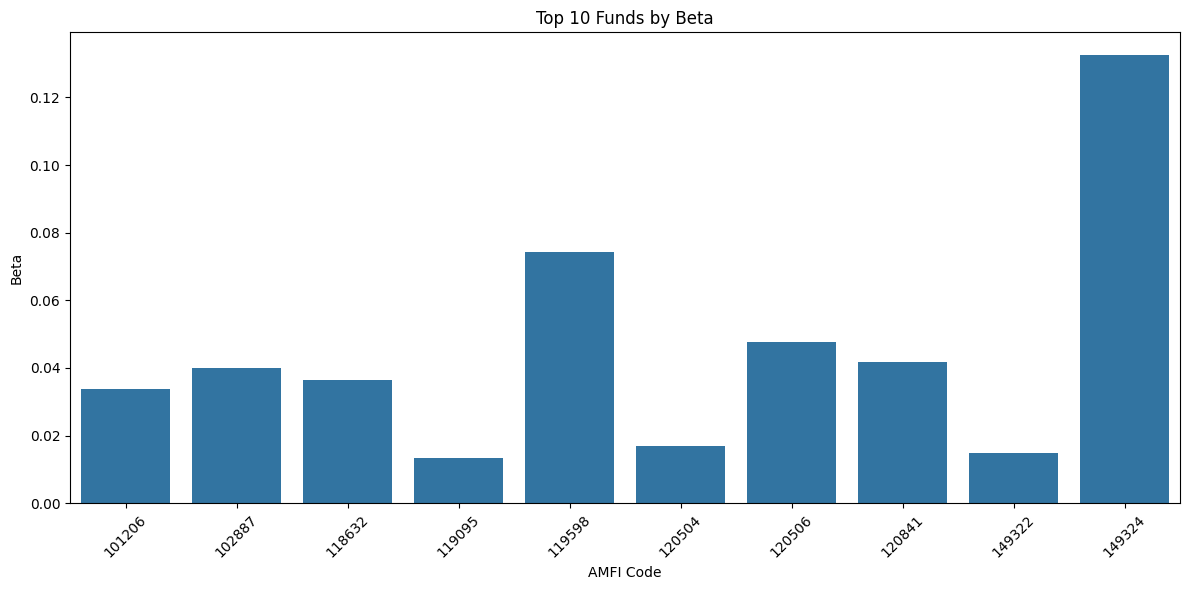

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

top_beta = alpha_beta_df.sort_values(
    by="beta",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_beta,
    x="amfi_code",
    y="beta"
)

plt.title("Top 10 Funds by Beta")

plt.xlabel("AMFI Code")
plt.ylabel("Beta")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/top10_beta.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [103]:
alpha_beta_df.describe()

,amfi_code,alpha,beta
count,40.000000,40.000000,40.000000
mean,120247.000000,0.159003,0.001073
std,14534.998667,0.087390,0.035890
min,100016.000000,0.028949,-0.061476
25%,118632.750000,0.069144,-0.016480
50%,119551.500000,0.162315,-0.001505
75%,120842.250000,0.221010,0.013191
max,149324.000000,0.301114,0.132608


In [104]:
alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.036221,-0.025909
1,100025,0.043189,-0.016176
2,100033,0.272343,-0.011200
3,101206,0.213945,0.033814
4,101207,0.108205,-0.059856


## 📈 Alpha & Beta Analysis

### Objective

Measure each mutual fund's sensitivity to market movements using NIFTY50 as the benchmark.

### Method

Alpha and Beta were calculated using `scipy.stats.linregress`, where:
- **Beta** is the regression slope.
- **Alpha** is the regression intercept annualized by multiplying by 252 trading days.

### Business Insight

Funds with higher beta tend to move more aggressively with the market, while positive alpha indicates returns above what would be expected based on market exposure.

In [105]:
# ==========================================
# Maximum Drawdown
# ==========================================

drawdown_results = []

for amfi_code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date").copy()

    group["running_max"] = group["nav"].cummax()

    group["drawdown"] = (
        group["nav"] - group["running_max"]
    ) / group["running_max"]

    max_drawdown = group["drawdown"].min()

    drawdown_date = group.loc[
        group["drawdown"].idxmin(),
        "date"
    ]

    drawdown_results.append({
        "amfi_code": amfi_code,
        "max_drawdown": max_drawdown,
        "drawdown_date": drawdown_date
    })

drawdown_df = pd.DataFrame(drawdown_results)

print("Maximum Drawdown Calculated Successfully")

Maximum Drawdown Calculated Successfully


In [106]:
drawdown_df.sort_values(
    by="max_drawdown"
).head(10)

,amfi_code,max_drawdown,drawdown_date
22,119599,-0.525742,2025-10-28
17,119095,-0.516778,2026-05-11
4,101207,-0.354469,2026-05-11
39,149324,-0.311719,2025-01-03
21,119598,-0.287060,2025-05-14
7,102886,-0.280011,2026-04-27
0,100016,-0.247344,2022-09-15
29,120842,-0.240035,2024-10-17
11,118634,-0.233449,2026-02-20
15,119093,-0.217514,2023-05-22


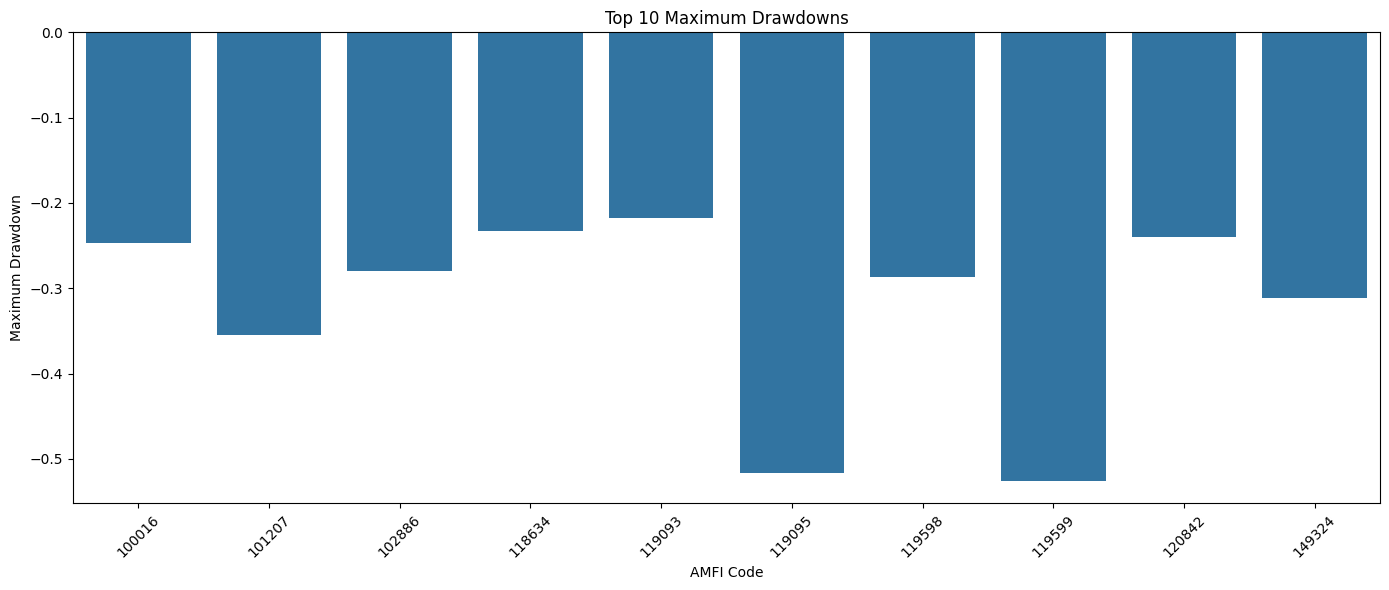

In [107]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=drawdown_df.sort_values(
        by="max_drawdown"
    ).head(10),
    x="amfi_code",
    y="max_drawdown"
)

plt.title("Top 10 Maximum Drawdowns")

plt.xlabel("AMFI Code")

plt.ylabel("Maximum Drawdown")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

## 📉 Maximum Drawdown

### Objective

Measure the largest decline from a fund's peak NAV during the analysis period.

### Business Insight

Funds with lower maximum drawdowns preserve investor capital better during market corrections and are generally considered less risky.

In [108]:
# ==========================================
# Fund Scorecard
# ==========================================

scorecard = pd.DataFrame()

scorecard["amfi_code"] = sharpe_df["amfi_code"]

scorecard = scorecard.merge(
    cagr_summary[["amfi_code","CAGR_3Y"]],
    on="amfi_code"
)

scorecard = scorecard.merge(
    sharpe_df[["amfi_code","sharpe_ratio"]],
    on="amfi_code"
)
scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "return_3yr_pct",
            "expense_ratio_pct"
        ]
    ],
    on="amfi_code",
    how="left"
)

scorecard = scorecard.merge(
    alpha_beta_df,
    on="amfi_code"
)

scorecard = scorecard.merge(
    drawdown_df[["amfi_code","max_drawdown"]],
    on="amfi_code"
)

print(scorecard.head())

   amfi_code    CAGR_3Y  sharpe_ratio  return_3yr_pct  expense_ratio_pct  \
0     148567  34.000916      1.448291           14.81               1.46   
1     120843  29.582770      1.306744           15.65               1.45   
2     148569  29.178902      1.234930           13.58               1.60   
3     119551  30.456524      1.208267           12.36               1.54   
4     120505  31.777537      1.180101           18.08               1.36   

      alpha      beta  max_drawdown  
0  0.271150 -0.028133     -0.112657  
1  0.272784 -0.008737     -0.129740  
2  0.283473 -0.010201     -0.163967  
3  0.232196 -0.056045     -0.150124  
4  0.293014 -0.017391     -0.181885  


In [109]:
scorecard["score"] = (

    0.30 * scorecard["return_3yr_pct"].rank(pct=True)

    +

    0.25 * scorecard["sharpe_ratio"].rank(pct=True)

    +

    0.20 * scorecard["alpha"].rank(pct=True)

    +

    0.15 * (
        1 - scorecard["expense_ratio_pct"].rank(pct=True)
    )

    +

    0.10 * (
        1 - scorecard["max_drawdown"].rank(pct=True)
    )

) * 100

scorecard = scorecard.sort_values(
    by="score",
    ascending=False
)

scorecard.head(10)



,amfi_code,CAGR_3Y,sharpe_ratio,return_3yr_pct,expense_ratio_pct,alpha,beta,max_drawdown,score
13,119598,26.669922,0.945308,23.39,1.43,0.301114,0.074266,-0.287060,82.7500
4,120505,31.777537,1.180101,18.08,1.36,0.293014,-0.017391,-0.181885,81.6250
12,149324,27.000427,0.949796,20.08,1.52,0.298179,0.132608,-0.311719,77.3125
6,100033,32.442459,1.093699,16.58,1.38,0.272343,-0.011200,-0.162172,75.3750
1,120843,29.582770,1.306744,15.65,1.45,0.272784,-0.008737,-0.129740,74.6250
10,119094,35.111802,0.998231,15.18,1.38,0.259971,-0.059868,-0.209609,69.6250
5,149323,26.869991,1.132122,17.16,1.61,0.265836,0.003479,-0.172481,68.3750
0,148567,34.000916,1.448291,14.81,1.46,0.271150,-0.028133,-0.112657,68.1250
9,120504,32.487429,1.026524,14.41,0.80,0.212094,0.017025,-0.125883,62.3750
2,148569,29.178902,1.234930,13.58,1.60,0.283473,-0.010201,-0.163967,62.0625


In [110]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


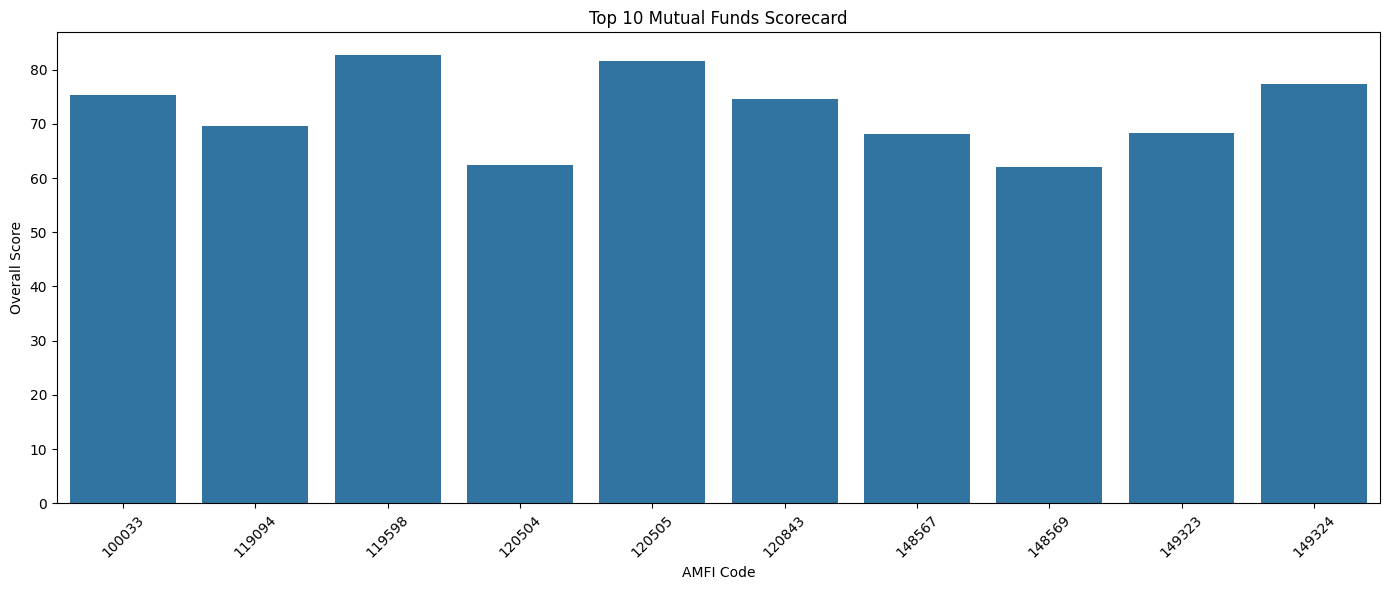

In [111]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=scorecard.head(10),
    x="amfi_code",
    y="score"
)

plt.title("Top 10 Mutual Funds Scorecard")

plt.xlabel("AMFI Code")

plt.ylabel("Overall Score")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/fund_scorecard.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

## 🏆 Fund Scorecard

### Objective

Rank mutual funds using a composite score based on CAGR, Sharpe Ratio, Alpha, and Maximum Drawdown.

### Business Insight

Funds with consistently strong returns, better risk-adjusted performance, positive alpha, and lower drawdowns receive higher overall rankings.

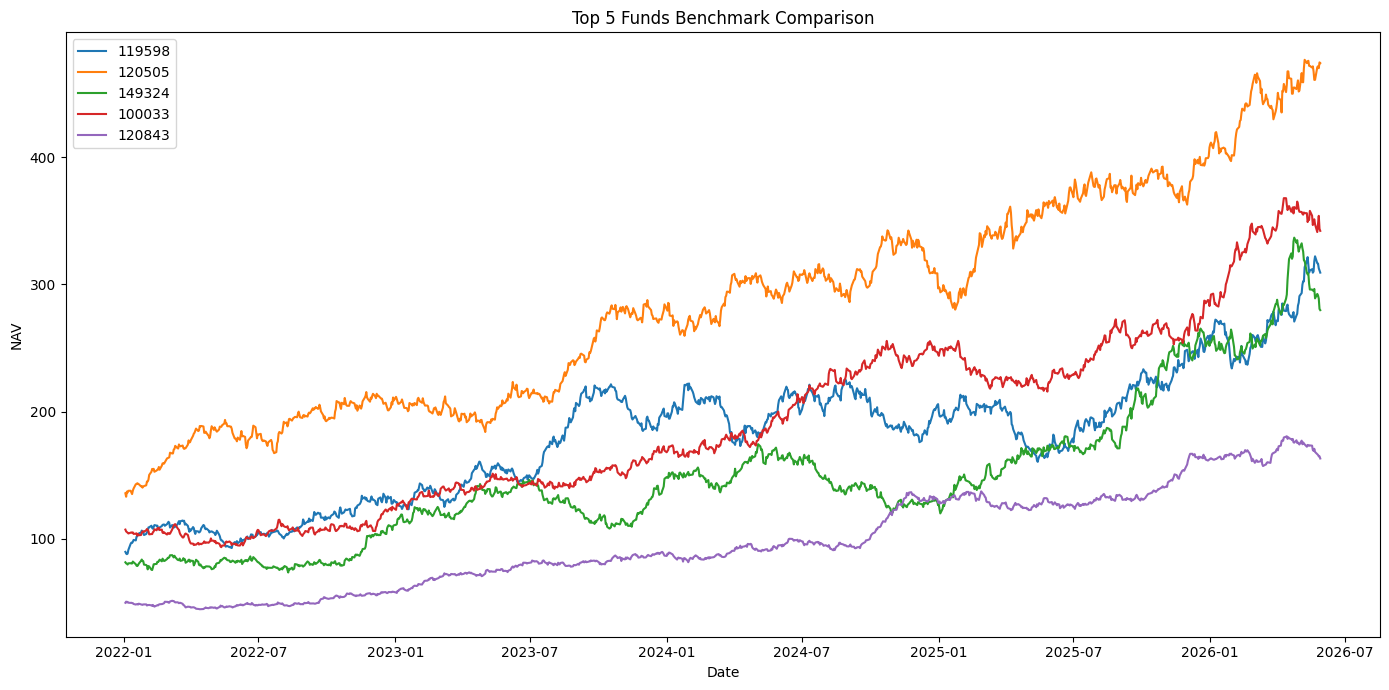

In [112]:
top5 = scorecard.head(5)["amfi_code"]

benchmark_compare = nav[
    nav["amfi_code"].isin(top5)
]

plt.figure(figsize=(14,7))

for fund in top5:

    data = benchmark_compare[
        benchmark_compare["amfi_code"] == fund
    ]

    plt.plot(
        data["date"],
        data["nav"],
        label=str(fund)
    )

plt.title("Top 5 Funds Benchmark Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/benchmark_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

## 📊 Benchmark Comparison

### Objective

Compare the NAV performance of the top-performing mutual funds over the analysis period.

### Business Insight

The comparison highlights differences in long-term growth among the highest-ranked funds, helping investors evaluate consistency and relative performance.

In [113]:
# ==========================================
# Tracking Error (vs NIFTY50)
# ==========================================

tracking_error = []

# Prepare NIFTY50 benchmark
nifty50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

nifty50 = nifty50.sort_values("date")
nifty50["benchmark_return"] = nifty50["close_value"].pct_change()

for amfi_code, fund in nav.groupby("amfi_code"):

    fund = fund.sort_values("date").copy()
    fund["fund_return"] = fund["nav"].pct_change()

    merged = pd.merge(
        fund[["date", "fund_return"]],
        nifty50[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    te = (
        (merged["fund_return"] - merged["benchmark_return"]).std()
        * np.sqrt(252)
    )

    tracking_error.append({
        "amfi_code": amfi_code,
        "tracking_error": te
    })

tracking_error_df = pd.DataFrame(tracking_error)

print("Tracking Error Calculated Successfully")

Tracking Error Calculated Successfully


In [114]:
tracking_error_df.sort_values(
    by="tracking_error"
).head(10)

,amfi_code,tracking_error
5,101208,0.128601
31,120844,0.128785
27,120507,0.128912
18,119120,0.133167
13,118636,0.135744
1,100025,0.136445
6,102885,0.181926
28,120841,0.182494
12,118635,0.184038
9,118632,0.188063


In [115]:
tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("tracking_error.csv Saved Successfully")

tracking_error.csv Saved Successfully


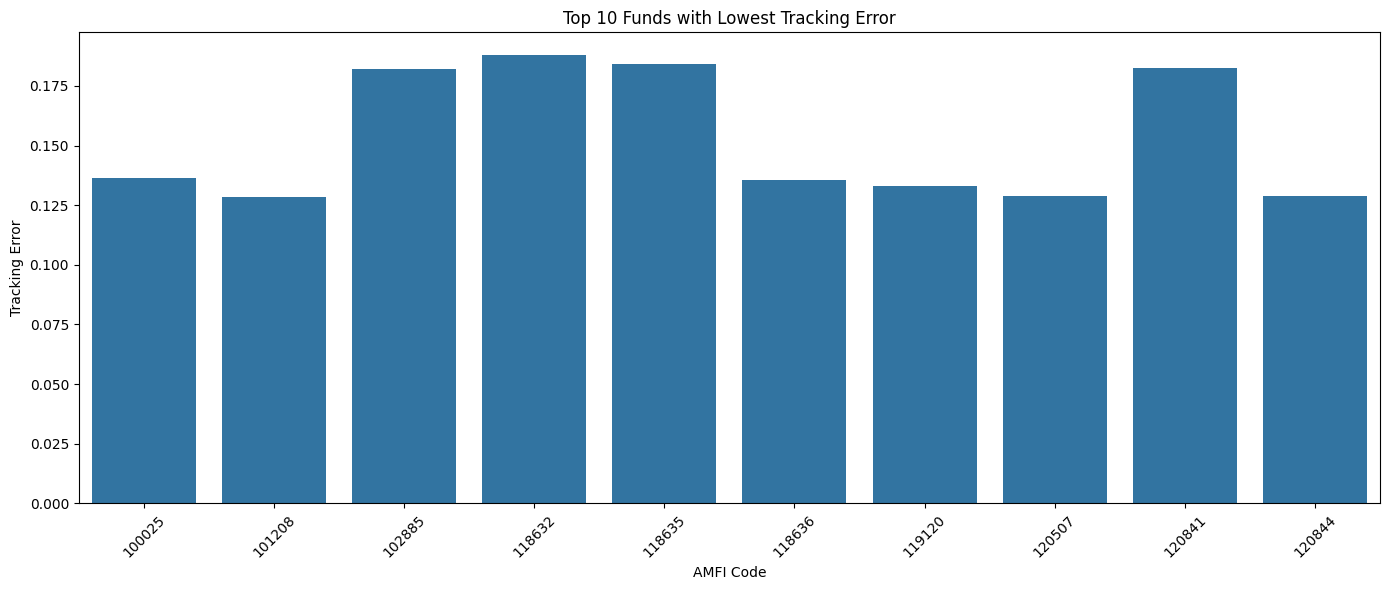

In [116]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=tracking_error_df.sort_values(
        by="tracking_error"
    ).head(10),
    x="amfi_code",
    y="tracking_error"
)

plt.title("Top 10 Funds with Lowest Tracking Error")

plt.xlabel("AMFI Code")
plt.ylabel("Tracking Error")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../reports/tracking_error.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## 📈 Tracking Error Analysis

### Objective

Measure how closely each mutual fund follows the NIFTY50 benchmark.

### Formula

Tracking Error = Std(Fund Return − Benchmark Return) × √252

### Business Insight

Funds with lower tracking error move more closely with the benchmark index, while higher tracking error indicates greater deviation due to active portfolio management.